In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from PIL import Image
import pickle

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# train_dir="../input/signature-verification-dataset-iraninan/train"
# test_dir="../input/signature-verification-dataset-iraninan/test"

train_dir="data/signature-verification-dataset/sign_data/train"
test_dir="data/signature-verification-dataset/sign_data/test"

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
SIZE = 224

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
def find_files_in_folder(path, folder_name):
    folder_path = None
    for root, dirs, files in os.walk(path):
        if folder_name in dirs:
            folder_path = os.path.join(root, folder_name)
            break
    img1 = []
    if folder_path:
        files = os.listdir(folder_path)
        for file in files:
            folder_name = os.path.dirname(file)
            file_name = os.path.basename(file)
            img1.append(file_name)
        return img1
    else:
        return None
    

train_data_names = []
test_data_names = []

train_data = []
train_labels = []

real_images = []
forged_images = []

for per in os.listdir(train_dir):
    for data in glob.glob(train_dir+'/'+per+'/*.*'):
        
        train_data_names.append(data)
        
        if per[-1]=='g':
            img = cv2.imread(data)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (SIZE,SIZE))
            forged_images.append([img])
#             train_labels.append(np.array(1))
        else:
            img = cv2.imread(data)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (SIZE,SIZE))
            real_images.append([img])
#             train_labels.append(np.array(0))

# train_data = np.array(train_data)/255.0
# train_labels = np.array(train_labels)
print("number of real_images",len(real_images))
#Test Data

test_data = []
test_labels = []

for per in os.listdir(test_dir):
    for data in glob.glob(test_dir+'/'+per+'/*.*'):
        test_data_names.append(data)
        
        if per[-1]=='g':
            img = cv2.imread(data)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (SIZE,SIZE))
            forged_images.append([img])
#             test_labels.append(np.array(1))
        else:
            img = cv2.imread(data)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (SIZE,SIZE))
            real_images.append([img])
#             test_labels.append(np.array(0))

# test_data = np.array(test_data)/255.0
# test_labels = np.array(test_labels)



# # Load the real signature images

# for filename in os.listdir(train_dir):
#     for file in filename:
#         files_in_folder = find_files_in_folder(train_dir, file)
#         if "-f" in file:
#             forged_images.append(file)
#         else:
#             real_images.append(file)
#     image = cv2.imread(os.path.join(train_dir, filename))
#     if image is not None:
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#         image = cv2.resize(image, (224, 224))
#         real_images.append(image)

# # Load the forged signature images

# for filename in os.listdir(test_dir):
#     for file in filename:
#         files_in_folder = find_files_in_folder(test_dir, file)
#         if "-f" in file:
#             forged_images.append(file)
#         else:
#             real_images.append(file)
#     image = cv2.imread(os.path.join(forged_path, filename))
#     if image is not None:
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#         image = cv2.resize(image, (224, 224))
#         forged_images.append(image)

# Convert the images to numpy arrays
real_images = np.array(real_images)
forged_images = np.array(forged_images)

# Create the labels (0 for real, 1 for forged)
real_labels = np.zeros((real_images.shape[0], 1))
forged_labels = np.ones((forged_images.shape[0], 1))

print("number of real_images",len(real_images))
print("number of forged_images",len(forged_images))

number of real_images 887
number of real_images 1139
number of forged_images 1010


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# Categorical labels
# print(train_labels.shape)
# train_labels = to_categorical(train_labels)
# print(train_data.shape)
# Reshaping
# train_data = train_data.reshape(-1, SIZE, 2)
# test_data = test_data.reshape(-1, SIZE, 3)
# print(train_data.shape[0])
# print(test_data.shape[0])
# train_data = train_data.reshape((train_data.shape[0], train_data.shape[1], train_data.shape[2] * 1))
# test_data = test_data.reshape((test_data.shape[0], test_data.shape[1], test_data.shape[2] * 1))
# print(train_data.shape)
# print(test_data.shape)

# Concatenate the real and forged images and labels
images = np.concatenate((real_images, forged_images))
labels = np.concatenate((real_labels, forged_labels))

# Split the data into training and validation sets
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
print(train_data.shape)
print(test_data.shape)

(1719, 1, 224, 224)
(430, 1, 224, 224)


In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
print(train_labels.shape)

(1719, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 256)                 │         492,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 493,058 (1.88 MB)

 Trainable params: 493,058 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - accuracy: 0.5159 - loss: 1.0066 - val_accuracy: 0.5378 - val_loss: 0.6911
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - accuracy: 0.5264 - loss: 0.7021 - val_accuracy: 0.5378 - val_loss: 0.6903
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 0.5514 - loss: 0.6920 - val_accuracy: 0.5378 - val_loss: 0.6905
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - accuracy: 0.5053 - loss: 0.6974 - val_accuracy: 0.4622 - val_loss: 0.7317
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 0.5009 - loss: 0.7016 - val_accuracy: 0.4622 - val_loss: 0.7313


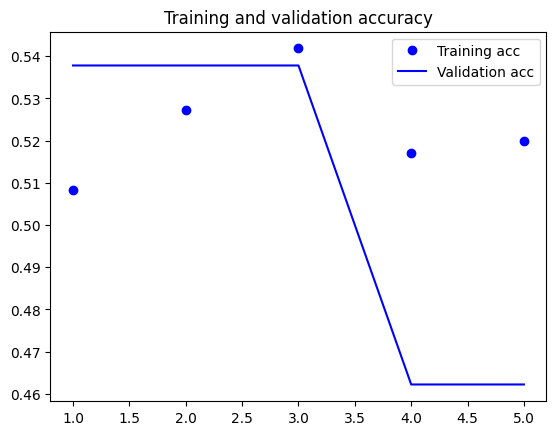

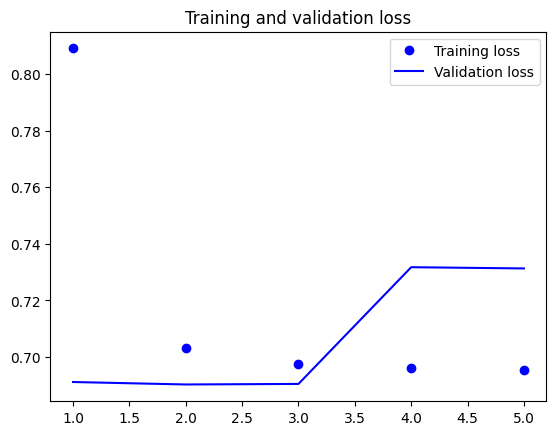

In [7]:
# --- [CELL 6]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# === BEFORE (original) ===
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from sklearn.model_selection import train_test_split
# 
# # load the data
# #(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()
# 
# 
# train_data = train_data.astype('float32') / 255
# test_data = test_data.astype('float32') / 255
# 
# # define the model
# model = keras.Sequential([
#     layers.LSTM(256, input_shape=(train_data.shape[1], train_data.shape[2])),
#     layers.Dense(2, activation='softmax')
# ])
# 
# model.compile(optimizer='rmsprop',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])
# 
# model.summary()
# 
# # define callbacks
# early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
# 
# # train the model
# history = model.fit(train_data, train_labels, batch_size=32, epochs=10, validation_split=.2, callbacks=[early_stop])
# 
# # plot accuracy and loss
# import matplotlib.pyplot as plt
# 
# acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']
# loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs = range(1, len(acc) + 1)
# 
# plt.plot(epochs, acc, 'bo', label='Training acc')
# plt.plot(epochs, val_acc, 'b', label='Validation acc')
# plt.title('Training and validation accuracy')
# plt.legend()
# 
# plt.figure()
# 
# plt.plot(epochs, loss, 'bo', label='Training loss')
# plt.plot(epochs, val_loss, 'b', label='Validation loss')
# plt.title('Training and validation loss')
# plt.legend()
# 
# plt.show()

# === AFTER (edited) ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Normalize
train_data = train_data.astype('float32') / 255
test_data = test_data.astype('float32') / 255

# Current shape: (N, 1, 224, 224) -> reshape to (N, 224, 224) for LSTM (timesteps=224, features=224)
train_data = train_data.reshape(train_data.shape[0], train_data.shape[2], train_data.shape[3])
test_data = test_data.reshape(test_data.shape[0], test_data.shape[2], test_data.shape[3])

model = keras.Sequential([
    keras.Input(shape=(train_data.shape[1], train_data.shape[2])),
    layers.LSTM(256),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(train_data, train_labels, batch_size=32, epochs=10, validation_split=.2, callbacks=[early_stop])

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [8]:
# Regression check: image training must use a 4D CNN input pipeline.
assert isinstance(model.layers[0], tf.keras.layers.Conv2D), "First layer should be Conv2D for image tensors"
assert model.input_shape == (None, 224, 224, 1), f"Unexpected model input shape: {model.input_shape}"
assert "accuracy" in history.history and "val_accuracy" in history.history, "Training history metrics missing"
assert len(history.history["accuracy"]) >= 1, "Training did not run for at least one epoch"

AssertionError: First layer should be Conv2D for image tensors